In [2]:
import zipfile
import io
import os
import numpy as np
import numpy.random as random
import scipy as sp
import pandas as pd
import xgboost as xgb
from pandas import Series, DataFrame
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
%matplotlib inline

# Display up to three decimal places
%precision 3

'%.3f'

In [3]:
customers = pd.read_csv("../data/customers.csv")
geography = pd.read_csv("../data/geography.csv")
inventory = pd.read_csv("../data/inventory.csv")
order_items = pd.read_csv("../data/order_items.csv")
orders = pd.read_csv("../data/orders.csv")
payments = pd.read_csv("../data/payments.csv")
products = pd.read_csv("../data/products.csv")
promotions = pd.read_csv("../data/promotions.csv")
returns = pd.read_csv("../data/returns.csv")
reviews = pd.read_csv("../data/reviews.csv")
sales = pd.read_csv("../data/sales.csv")
shipments = pd.read_csv("../data/shipments.csv")
web_traffic = pd.read_csv("../data/web_traffic.csv")
sample = pd.read_csv("../data/sample_submission.csv")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27100\2434114870.py:4: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("../data/order_items.csv")


In [ ]:
sales.set_index("Date", inplace=True)
sales.index = pd.to_datetime(sales.index)

In [ ]:
sales

,Revenue,COGS
Date,,
2012-07-04,5123547.94,3982991.19
2012-07-05,2751773.45,2150580.23
2012-07-06,3054029.42,2517632.84
2012-07-07,2667930.94,2108246.62
2012-07-08,2360851.90,1808622.79
2012-07-09,3548386.46,2787841.68
2012-07-10,5234938.62,4044438.84
2012-07-11,5582884.78,4338313.07
2012-07-12,5734632.02,4458811.27


In [29]:
train = sales.loc[sales.index <= '01-01-2021']
test = sales.loc[sales.index > '01-01-2021']
train_rev = train['Revenue'].copy()
train_cogs = train['COGS'].copy()
test_rev = test['Revenue'].copy()
test_cogs = test['COGS'].copy()

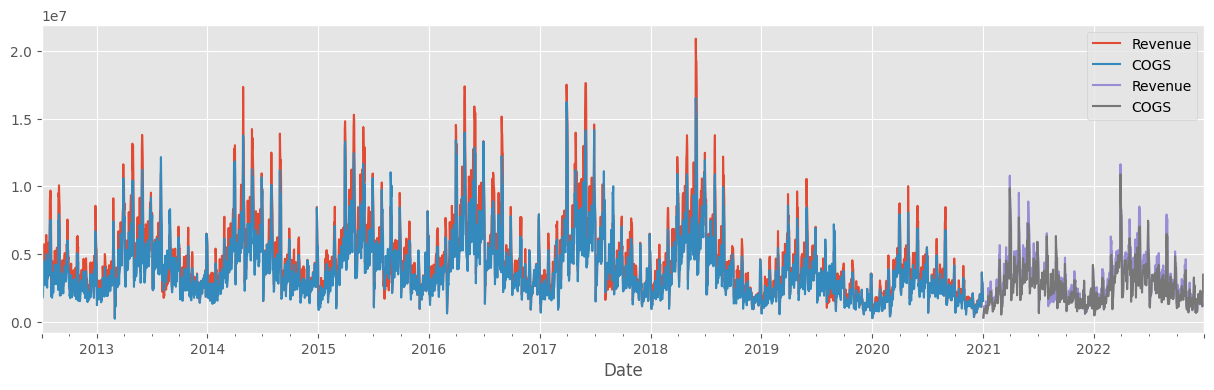

In [27]:
fig, ax = plt.subplots(figsize=(15,4))
train.plot(ax=ax,label = 'Training Set')
test.plot(ax=ax, label = 'Test Set')
plt.show()

<Axes: xlabel='Date'>

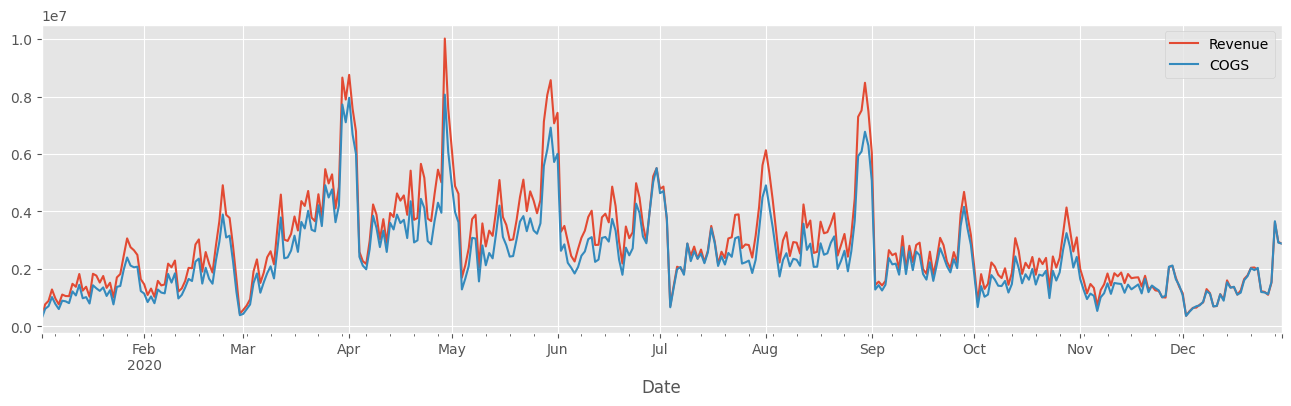

In [40]:
sales.loc[(sales.index > '01-01-2020') & (sales.index < '12-31-2020')].plot(figsize=(16,4))

<Axes: xlabel='Date'>

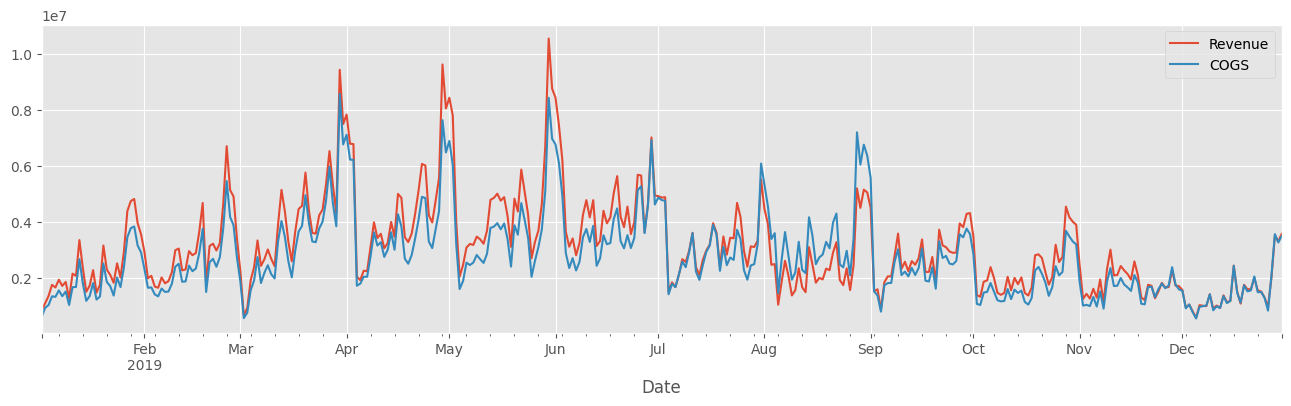

In [39]:
sales.loc[(sales.index > '01-01-2019') & (sales.index < '12-31-2019')].plot(figsize=(16,4))

three big spikes: april may jun (maybe september). Start of everymonth tends to have a spike.

In [ ]:
sales['days'] = sales.index.day
